## This exercise is about M2_part2
Be sure to examine and follow the rubric for this assignment. The report should contain an introduction, results, discussion and conclusion. Answers should be more comprehensive than above. Take care to format figures, tables etc. Justify your actions and conclusions. 
### Question 
- Can fecal microbiome sampling replace biochemical biomarkers for identifying different stages of bowel cancer? 
- 45 bowel cancer patients (from stage 1 to 4, with 4 being worst) were tested using 9 blood biomarkers and fecal microbiome sampling containing 23 bacteria (from Order to Species). Metadata includes patient's declared gender. 
- Carry out preprocessing, PLS, modeling and classification on the microbiome and biomarker data, along with any relevant analyses learned in M1 + M2. 

### Consider:
- Which biomarkers and bacteria are associated with the different stages of bowel cancer?
- Can you identify the relevant variables using Effects Plots?
- How well does the microbiome model the biomarkers?
- What can the bacteria identify that biomarkers cannot?
- Do bacteria or biomarkers classify the disease levels better?
- Are there any issues with the design?

## Preprocessing

1. loading the data 

In [1]:
import pandas as pd 

In [2]:
cancer_df = pd.read_csv('M3_CancerMod.csv')
cancer_df

,Sample,Condition,Set,Gender,Age,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,...,Christensenellaceae,Helicobacteraceae,Bizzozeronii,H.Pylori,Ruminococcaceae,Oscillospira,Ruminococcus,Mogibacteriaceae,Sutterella,Anaeroplasma
0,1,Stage3,A,F,48,32.38,8.643,1.023,48.52,4.017,...,0.000000,0.004372,0.021419,0.008131,0.030453,0.170548,0.014665,0.000000,0.000000,0.000000
1,2,Stage2,A,M,49,37.40,NaN,0.921,51.58,5.290,...,0.000151,0.004317,0.012514,0.002909,0.041298,0.263042,0.013428,0.000151,0.007611,0.000000
2,3,Stage3,A,M,40,52.16,8.682,0.490,72.83,9.282,...,0.000000,0.005343,0.035647,0.005786,0.014161,0.149201,0.013814,0.000154,0.000000,0.000000
3,4,Stage2,A,F,54,25.18,4.307,0.560,34.20,2.920,...,0.000195,0.003955,0.012579,0.002905,0.025016,0.257947,0.024303,0.000207,0.000000,0.000207
4,5,Stage2,A,M,36,34.67,8.439,1.140,49.83,3.666,...,0.000000,0.005404,0.022802,0.002335,0.029067,0.172859,0.008122,0.000300,0.000000,0.001178
5,6,Stage1,A,M,24,39.27,5.255,0.698,52.06,4.934,...,0.000267,0.003412,0.008172,0.004606,0.060392,0.188013,0.019195,0.000520,0.000000,0.003749
6,7,Stage4,A,M,57,37.82,6.475,0.572,52.56,5.941,...,0.000000,0.007837,0.082707,0.015646,0.028597,0.134221,0.016230,0.000000,0.000000,0.000000
7,8,Stage2,A,F,54,37.44,7.766,1.033,52.76,4.502,...,0.000192,0.006303,0.014867,0.003817,0.041748,0.168266,0.013039,0.000160,0.000000,0.008821
8,9,Stage4,A,F,56,41.71,9.825,0.683,70.47,16.126,...,0.000000,0.005387,0.032978,0.019856,0.024137,0.129154,0.008889,0.000000,0.000000,0.000000
9,10,Stage4,A,M,66,51.11,9.863,1.094,75.62,11.245,...,0.000000,0.007309,0.051234,0.010525,0.019563,0.111580,0.010768,0.000000,0.000000,0.000000


Drop rows with any NaN values by index

In [3]:
# drops = cancer_df[cancer_df.isna().any(axis=1)].index.tolist()
# print(drops)
# cancer_df = cancer_df.drop(drops)
# cancer_df

In [4]:
print(cancer_df.columns)
print(cancer_df.shape)


Index(['Sample', 'Condition', 'Set', 'Gender', 'Age', 'miRNA10', 'miRNA12',
       'miRNA15', 'miRNA24', 'miRNA36', 'GDf13', 'GDf9', 'GDf6', 'GDf5',
       'Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter',
       'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum',
       'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae',
       'Helicobacteraceae', 'Bizzozeronii', 'H.Pylori', 'Ruminococcaceae',
       'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella',
       'Anaeroplasma'],
      dtype='object')
(45, 36)


Let's identify data with biomarkers, bacterias and stages.


In [30]:
# 9 biomakers
biomarkers_list = cancer_df.columns[5:14].to_list()
print(len(biomarkers_list))
# fecal microbiome sampling containing 23 bacteria
bacteria_list = cancer_df.columns[14:].to_list()
print(bacteria_list)
print(len(bacteria_list))



9
['Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter', 'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum', 'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae', 'Helicobacteraceae', 'Bizzozeronii', 'H.Pylori', 'Ruminococcaceae', 'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella', 'Anaeroplasma']
22


Replace outliers with median value by same stage groups

In [8]:
import numpy as np
import pandas as pd

# Function to identify and replace outliers and NaN values with median
def replace_outliers_and_nan_with_median(df, Condition, replaced_columns):
    for column in replaced_columns:
        # Group by the specified condition
        grouped = df.groupby(Condition)

        # Define a function to replace outliers and NaN with median
        def replace_outliers_and_nan(group):
            # Calculate Q1 (25th percentile) and Q3 (75th percentile)
            Q1 = group[column].quantile(0.25)
            Q3 = group[column].quantile(0.75)
            IQR = Q3 - Q1

            # Define the outlier range
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR

            # Calculate the median for the group
            median = group[column].median()

            # Replace outliers with the median
            group[column] = np.where((group[column] < lower_bound) | (group[column] > upper_bound), median, group[column])

            # Replace NaN values with the median
            group[column].fillna(median, inplace=True)

            return group

        # Apply the replacement function to each group
        df = grouped.apply(replace_outliers_and_nan).reset_index(level=Condition, drop=True)

    return df

# List of columns to process
replaced_columns = [*biomarkers_list, *bacteria_list]  # Modify this list to include all columns

# Replace outliers and NaN values, grouped by the 'Condition' column
cancer_df_outlier_and_nan = replace_outliers_and_nan_with_median(cancer_df, 'Condition', replaced_columns)

# Display the resulting DataFrame and statistics
cancer_df_outlier_and_nan.describe()


C:\Users\Yao_L\AppData\Local\Temp\ipykernel_25832\1167689690.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  group[column].fillna(median, inplace=True)
C:\Users\Yao_L\AppData\Local\Temp\ipykernel_25832\1167689690.py:28: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example

,Sample,Age,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,GDf13,GDf9,GDf6,...,Christensenellaceae,Helicobacteraceae,Bizzozeronii,H.Pylori,Ruminococcaceae,Oscillospira,Ruminococcus,Mogibacteriaceae,Sutterella,Anaeroplasma
count,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,...,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.000000,45.0,45.000000
mean,23.000000,42.733333,42.036222,7.214189,0.759222,58.384667,7.039278,0.904178,0.914342,0.026911,...,0.000096,0.004610,0.028756,0.005524,0.037113,0.176455,0.013502,0.000180,0.0,0.000426
std,13.133926,11.761648,13.076135,2.180391,0.170712,18.330103,4.721443,0.141454,0.196244,0.009027,...,0.000133,0.001566,0.022312,0.003020,0.017547,0.048907,0.005072,0.000184,0.0,0.000888
min,1.000000,24.000000,22.730000,3.856000,0.406000,31.810000,1.974000,0.607000,0.457000,0.008000,...,0.000000,0.001320,0.008172,0.001717,0.014161,0.102180,0.004307,0.000000,0.0,0.000000
25%,12.000000,32.000000,35.250000,5.157000,0.656000,48.430000,3.962000,0.774000,0.808000,0.021000,...,0.000000,0.003597,0.014070,0.003270,0.024735,0.132169,0.010768,0.000000,0.0,0.000000
50%,23.000000,42.000000,37.820000,6.804000,0.772000,52.430000,5.096000,0.946000,0.906000,0.027000,...,0.000000,0.004317,0.020324,0.004606,0.030453,0.170548,0.013428,0.000154,0.0,0.000000
75%,34.000000,51.000000,44.330000,8.639000,0.854000,59.940000,9.282000,0.981000,1.031000,0.033000,...,0.000171,0.005399,0.032978,0.007056,0.048987,0.218955,0.014665,0.000307,0.0,0.000345
max,45.000000,69.000000,83.910000,11.852000,1.150000,115.520000,20.250000,1.171000,1.386000,0.047000,...,0.000522,0.008944,0.105245,0.015646,0.085260,0.267743,0.030330,0.000624,0.0,0.004769


Split the data into X and y 

In [9]:
# X explanatory data: which we used to predict
X = cancer_df_outlier_and_nan[bacteria_list]
# y : predictive targets
y = cancer_df_outlier_and_nan[biomarkers_list]
print(f'X data is {X}')
print(f'y data is {y}')

X data is     Helicobacter  Coriobacteriaceae  Bacteroidales  Campylobacter  \
5       0.000000           0.001502       0.027128       0.162136   
11      0.000000           0.000000       0.018854       0.168395   
15      0.000000           0.000864       0.018575       0.155126   
22      0.000000           0.000736       0.013029       0.155126   
23      0.000000           0.000000       0.020781       0.130926   
31      0.000182           0.001289       0.014944       0.089786   
32      0.000000           0.000993       0.010108       0.117329   
33      0.000000           0.000399       0.007986       0.160958   
36      0.000114           0.002790       0.015510       0.126012   
37      0.000000           0.000000       0.017823       0.245739   
40      0.000000           0.000000       0.025930       0.149294   
41      0.000000           0.000864       0.017072       0.047118   
1       0.000972           0.002406       0.008876       0.156171   
3       0.002036        

Explnatory Data Analysis

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

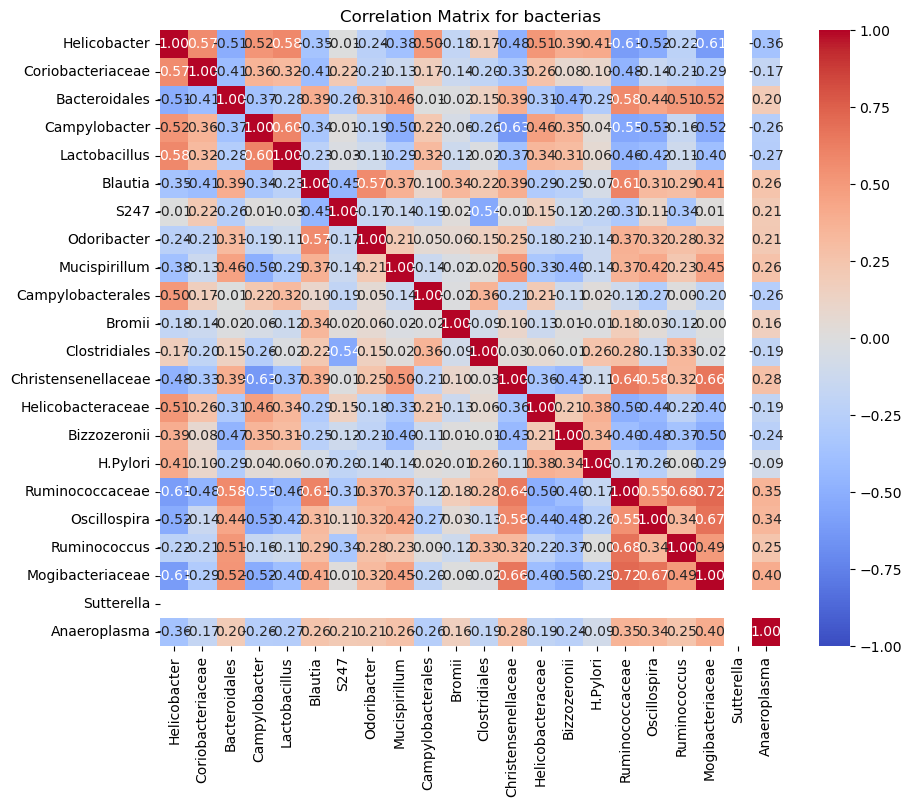

(45, 22)
(45, 22)


In [20]:
# calculate correlation matrix
corr_matrix = X.corr()
# Plotting the correlation matrix of features
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1)
plt.title('Correlation Matrix for bacterias')
plt.show()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column].abs()>0.9)]
X_dropped = X.drop(X[to_drop], axis=1)
print(X.shape)
print(X_dropped.shape)


# delete the features that highly correlated (>0.9)



## PLS 

Let's try to plot figure with 5 comps

In [11]:
X.columns

Index(['Helicobacter', 'Coriobacteriaceae', 'Bacteroidales', 'Campylobacter',
       'Lactobacillus', 'Blautia', 'S247', 'Odoribacter', 'Mucispirillum',
       'Campylobacterales', 'Bromii', 'Clostridiales', 'Christensenellaceae',
       'Helicobacteraceae', 'Bizzozeronii', 'H.Pylori', 'Ruminococcaceae',
       'Oscillospira', 'Ruminococcus', 'Mogibacteriaceae', 'Sutterella',
       'Anaeroplasma'],
      dtype='object')

In [36]:
bacteria_list

['Helicobacter',
 'Coriobacteriaceae',
 'Bacteroidales',
 'Campylobacter',
 'Lactobacillus',
 'Blautia',
 'S247',
 'Odoribacter',
 'Mucispirillum',
 'Campylobacterales',
 'Bromii',
 'Clostridiales',
 'Christensenellaceae',
 'Helicobacteraceae',
 'Bizzozeronii',
 'H.Pylori',
 'Ruminococcaceae',
 'Oscillospira',
 'Ruminococcus',
 'Mogibacteriaceae',
 'Anaeroplasma']

In [35]:
X.drop(columns=['Sutterella'])
# also delete from the list cause i'll use the list for name 
# bacteria_list.remove("Sutterella")
type(bacteria_list)
bacteria_list.remove("Sutterella")

ValueError: list.remove(x): x not in list

In [28]:

 
from sklearn.cross_decomposition import PLSRegression
from scipy.stats import zscore
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [13]:
y

,miRNA10,miRNA12,miRNA15,miRNA24,miRNA36,GDf13,GDf9,GDf6,GDf5
5,39.27,5.2550,0.698,52.060,4.9340,0.739,0.9704,0.033,0.0340
11,22.73,3.8560,0.659,31.810,3.1840,0.699,0.6200,0.031,0.0300
15,51.14,5.1570,0.854,49.595,12.2410,1.039,1.0480,0.032,0.0335
22,36.57,5.1570,0.931,49.595,12.8560,1.066,1.3860,0.023,0.0230
23,43.12,4.5200,0.792,58.010,5.0385,0.878,1.2600,0.029,0.0230
31,33.37,4.8230,0.696,45.410,5.0710,0.756,0.6320,0.034,0.0400
32,33.14,6.5630,0.973,46.490,3.6970,1.003,1.0690,0.026,0.0310
33,36.70,5.2650,0.851,49.830,5.0060,0.981,0.9920,0.025,0.0330
36,36.27,4.9770,0.796,48.430,4.5640,0.862,0.9060,0.042,0.0350
37,40.52,5.8830,0.857,55.880,6.3200,0.969,1.2510,0.040,0.0510


In [22]:
# build the model
pls = PLSRegression(n_components=5, scale=True)

# fit X and y
pls.fit(X, y)

PLSRegression(n_components=5)

In [23]:
# Extract loadings and scores
t_pls = pls.x_scores_
w_pls = pls.x_weights_
q_pls = pls.y_loadings_


In [24]:
# Plotting the PLS Bi-plot
plt.figure(figsize=(10,8))

# Extract loadings and scores
t_pls = pls.x_scores_
w_pls = pls.x_weights_
q_pls = pls.y_loadings_

<Figure size 1000x800 with 0 Axes>

In [ ]:
# Plot the w loadings (explanatory variables)
for i in range(len(w_pls)):
    plt.scatter(w_pls[i][0] * wscale, w_pls[i][1] * wscale, s=50, alpha=0.8, marker='^', edgecolor='black')
    plt.text(w_pls[i][0] * wscale, w_pls[i][1] * wscale, xnames[i], fontsize=7, color='black', alpha=0.8)

# Plot the q loadings (response variables)
for i in range(len(q_pls)):
    plt.scatter(q_pls[i][0] * qscale, q_pls[i][1] * qscale, s=400, alpha=0.8, marker='s', edgecolor='black')
    plt.text(q_pls[i][0] * qscale, q_pls[i][1] * qscale, cnames[i], fontsize=13, color='blue')

# Plot the samples (T)
used = []
scores = t_pls
for i in range(len(scores)):
    plt.text(scores[i][0] * sscale, scores[i][1] * sscale, myid[i], fontsize=10, color='green')
    if levs[i] in used:
        plt.scatter(scores[i][0] * sscale, scores[i][1] * sscale, s=100, alpha=0.6, color=colordic[levs[i]], edgecolor='black')
    else:
        plt.scatter(scores[i][0] * sscale, scores[i][1] * sscale, s=100, label=levs[i], color=colordic[levs[i]], alpha=0.6, edgecolor='black')
        used.append(levs[i])

# Add axis lines
plt.axhline(0, color='k', linestyle='-', linewidth=0.7)
plt.axvline(0, color='k', linestyle='-', linewidth=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')

# Add legend
plt.legend(title=cat, loc=4, fontsize='small')
plt.title('PLS Plot', fontsize=16)

plt.show()